# Task 2 — Unemployment Analysis with Python
### OIBSIP Data Science Internship

**Objective:** Explore regional and temporal trends in India's unemployment rate, 
with a focus on the impact of the COVID-19 pandemic.

**Dataset:** [Unemployment in India — Kaggle](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)
(two files: `Unemployment in India.csv` covering May 2019–Jun 2020, and 
`Unemployment_Rate_upto_11_2020.csv` covering Jan–Nov 2020 with region grouping and lat/long)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load the Data

In [2]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Strip whitespace from column names (dataset has leading spaces after commas)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
df1.head()


Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


**Note:** the second file duplicates the `Region` column name (once for state, once for 
zone e.g. "South"/"North"). We'll rename it to avoid ambiguity.

In [3]:
# df2 has two columns named "Region" — the second one is actually the zone (e.g. South, North)
cols = list(df2.columns)
cols[6] = "Zone"
df2.columns = cols
df2.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Zone,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 2. Data Cleaning

In [4]:
# Check for nulls
print("Dataset 1 nulls:\n", df1.isnull().sum())
print("\nDataset 2 nulls:\n", df2.isnull().sum())


Dataset 1 nulls:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Dataset 2 nulls:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
dtype: int64


In [5]:
# Dataset 1 has fully-blank trailing rows — drop them
df1 = df1.dropna().copy()

# Strip whitespace from all string columns in both dataframes
for col in df1.select_dtypes(include='object').columns:
    df1[col] = df1[col].str.strip()
for col in df2.select_dtypes(include='object').columns:
    df2[col] = df2[col].str.strip()

# Convert Date to datetime
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%m-%Y')

print("Dataset 1:", df1.shape, "| Date range:", df1['Date'].min(), "to", df1['Date'].max())
print("Dataset 2:", df2.shape, "| Date range:", df2['Date'].min(), "to", df2['Date'].max())


Dataset 1: (740, 7) | Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Dataset 2: (267, 9) | Date range: 2020-01-31 00:00:00 to 2020-10-31 00:00:00


/tmp/ipykernel_230/1081454463.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df1.select_dtypes(include='object').columns:
/tmp/ipykernel_230/1081454463.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for d

**Decision:** Dataset 1 (`Unemployment in India.csv`) has the longer time range 
(May 2019–Jun 2020), which is essential for a proper pre-COVID vs. post-COVID comparison. 
We'll use it as our primary dataset for the core analysis, and bring in Dataset 2 
(with its region/zone grouping) for a supplementary zonal view.

In [6]:
df = df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})
df.dtypes


Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object

In [7]:
df.describe()


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


## 3. Exploratory Data Analysis

### 3.1 Overall distribution of unemployment rate

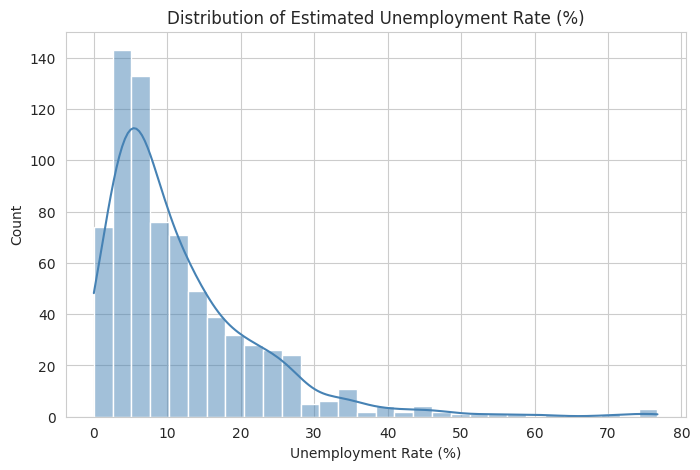

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment_Rate'], bins=30, kde=True, color='steelblue')
plt.title("Distribution of Estimated Unemployment Rate (%)")
plt.xlabel("Unemployment Rate (%)")
plt.savefig("screenshots/01_unemployment_distribution.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** the distribution is right-skewed — most regions/months sit in a 
"normal" band, but a long tail of much higher values appears, which is almost certainly 
driven by the COVID-19 lockdown spike in April–May 2020.

### 3.2 Region-wise average unemployment rate

In [9]:
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)
region_avg


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment_Rate, dtype: float64

### 3.3 Top 10 states with highest average unemployment rate

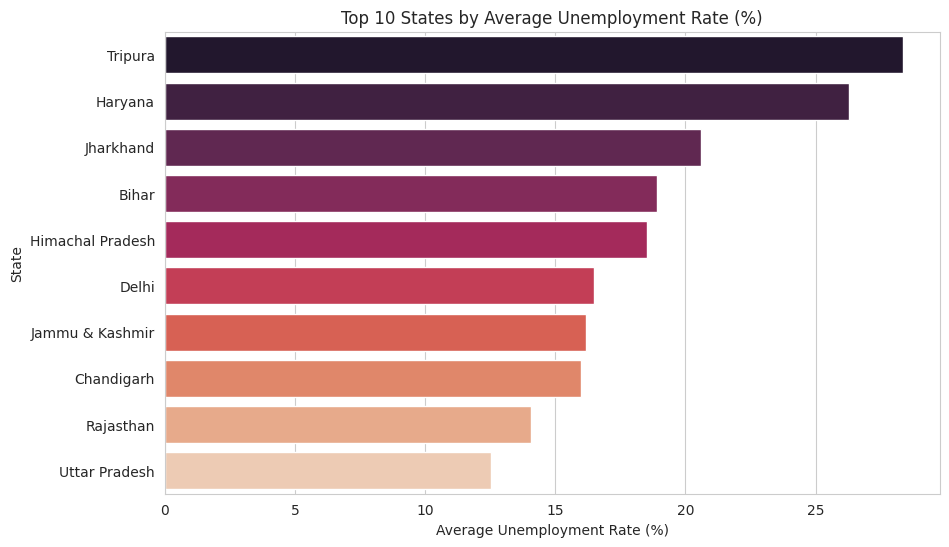

In [10]:
plt.figure(figsize=(10,6))
top10 = region_avg.head(10)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='rocket', legend=False)
plt.title("Top 10 States by Average Unemployment Rate (%)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.savefig("screenshots/02_top10_states_bar.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Tripura (28.4%), Haryana (26.3%), and Jharkhand (20.6%) have the 
highest average unemployment rates over the full period. These are consistently high 
throughout the dataset, suggesting structural labour market issues in these states that 
predate and go beyond the COVID-19 shock alone.

### 3.4 Month-wise national average trend

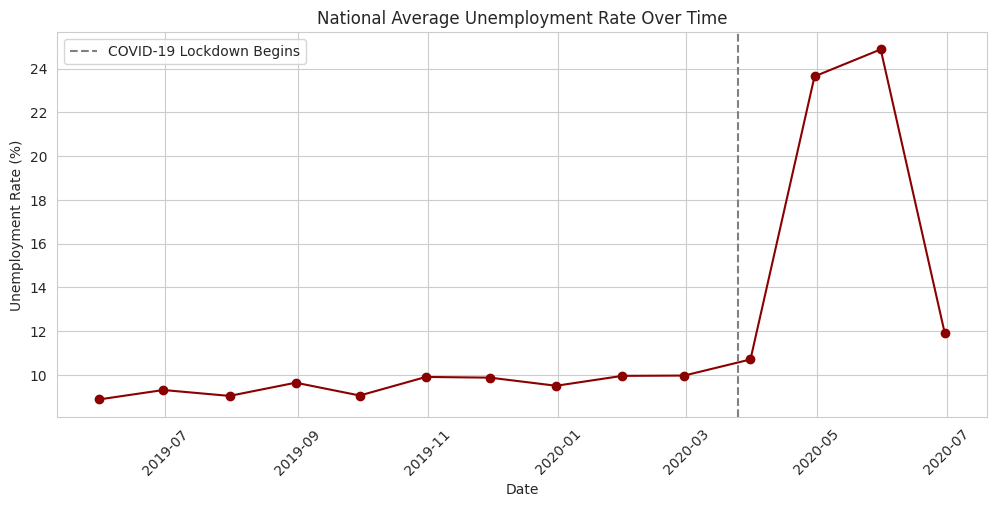

In [11]:
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='darkred')
plt.title("National Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.axvline(pd.Timestamp('2020-03-25'), color='gray', linestyle='--', label='COVID-19 Lockdown Begins')
plt.legend()
plt.xticks(rotation=45)
plt.savefig("screenshots/03_national_trend.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** a sharp, unmistakable spike in unemployment rate follows the national 
lockdown announced on March 25, 2020 — the clearest signal of COVID-19's labour market impact 
in this dataset.

### 3.5 Time-series trend for 3 major states

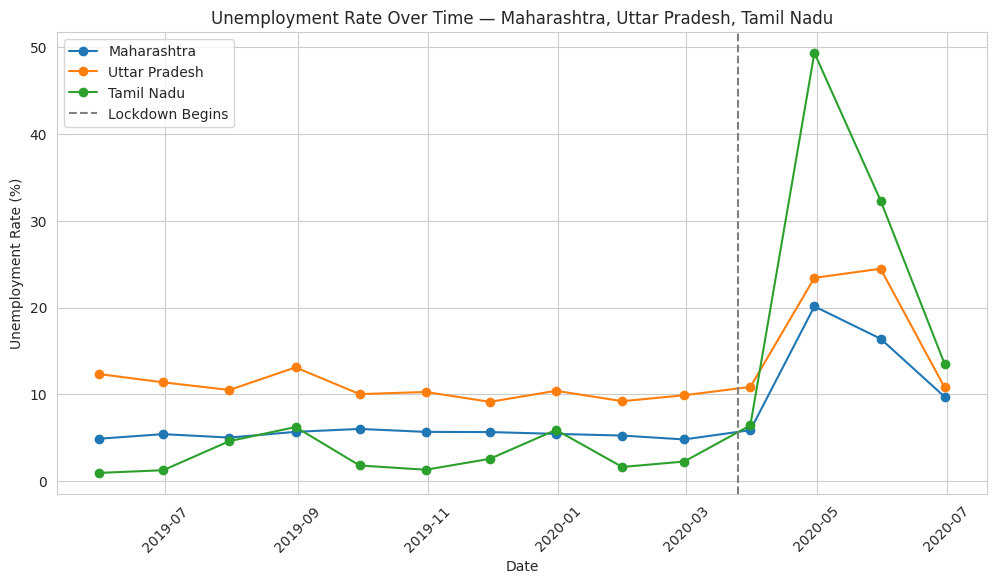

In [12]:
major_states = ['Maharashtra', 'Uttar Pradesh', 'Tamil Nadu']

plt.figure(figsize=(12,6))
for state in major_states:
    state_data = df[df['Region'] == state].groupby('Date')['Unemployment_Rate'].mean()
    plt.plot(state_data.index, state_data.values, marker='o', label=state)

plt.axvline(pd.Timestamp('2020-03-25'), color='gray', linestyle='--', label='Lockdown Begins')
plt.title("Unemployment Rate Over Time — Maharashtra, Uttar Pradesh, Tamil Nadu")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.savefig("screenshots/04_state_trends.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Tamil Nadu shows the sharpest spike around April-May 2020, rising from 
near-zero pre-lockdown levels into the mid-20s%, while Maharashtra and Uttar Pradesh also 
rise sharply but from higher pre-COVID baselines. All three show a partial recovery trend 
by June 2020, though none return fully to pre-lockdown levels within the data window.

### 3.6 Correlation heatmap

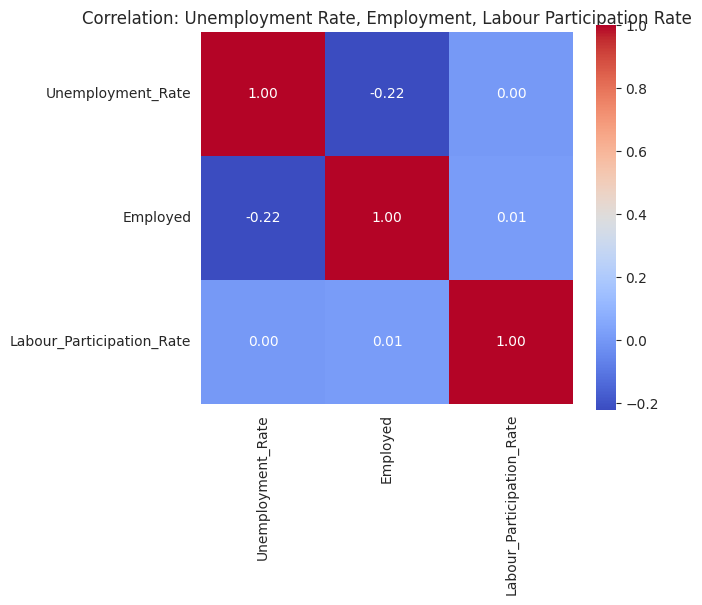

In [13]:
plt.figure(figsize=(6,5))
corr = df[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation: Unemployment Rate, Employment, Labour Participation Rate")
plt.savefig("screenshots/05_correlation_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Unemployment rate has a weak negative correlation with the number of 
people employed (-0.22), as expected. Interestingly, its correlation with labour 
participation rate is essentially zero (0.003) in this dataset — the lockdown appears to 
have pushed unemployment up without a corresponding, offsetting drop in the labour 
participation rate at the aggregate level.

### 3.7 Rural vs. Urban unemployment

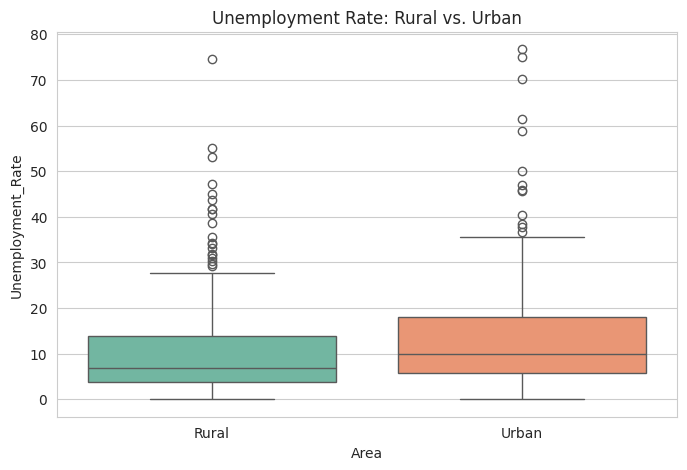

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Area', y='Unemployment_Rate', hue='Area', palette='Set2', legend=False)
plt.title("Unemployment Rate: Rural vs. Urban")
plt.savefig("screenshots/06_rural_vs_urban.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Urban areas show both a higher median unemployment rate (9.97% vs. 
6.76%) and higher variance than rural areas. This lines up with expectations: urban 
economies lean more heavily on in-person services and formal-sector jobs that paused 
entirely during lockdown, whereas rural employment (agriculture especially) was less 
disrupted.

## 4. Pre-COVID vs. Post-COVID Comparison

We define **pre-COVID** as before March 25, 2020 (the date India's national lockdown 
began) and **post-COVID** as on/after that date, within the data's available range 
(through June 2020).

In [15]:
lockdown_date = pd.Timestamp('2020-03-25')

df['Period'] = np.where(df['Date'] < lockdown_date, 'Pre-COVID', 'Post-COVID')

period_comparison = df.groupby('Period')[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].mean()
period_comparison


,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


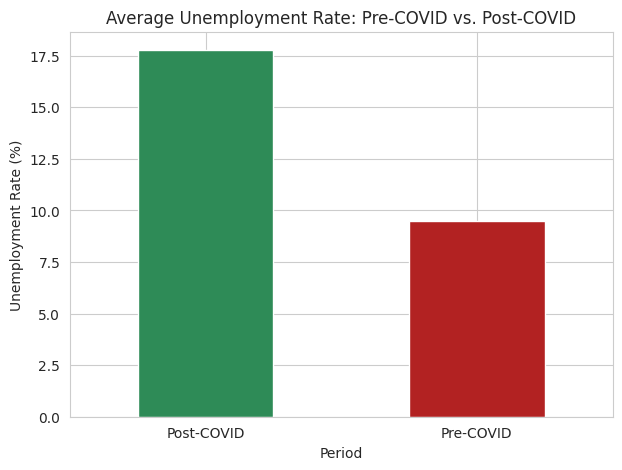

In [16]:
plt.figure(figsize=(7,5))
period_comparison['Unemployment_Rate'].plot(kind='bar', color=['seagreen', 'firebrick'])
plt.title("Average Unemployment Rate: Pre-COVID vs. Post-COVID")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.savefig("screenshots/07_pre_post_covid.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The average unemployment rate rose from **9.5% pre-COVID to 17.8% 
post-COVID** — an increase of roughly 8.3 percentage points, nearly double the pre-lockdown 
rate. Average labour participation rate also fell slightly (43.9% → 39.3%), and average 
employed population dropped from ~7.47M to ~6.52M, confirming the lockdown's broad 
disruption across all three metrics.

### 4.1 State-level impact: which states were hit hardest by COVID?

In [17]:
state_period = df.pivot_table(index='Region', columns='Period', values='Unemployment_Rate', aggfunc='mean')
state_period['Change'] = state_period['Post-COVID'] - state_period['Pre-COVID']
state_period.sort_values('Change', ascending=False).head(10)


Period,Post-COVID,Pre-COVID,Change
Region,,,
Puducherry,38.95500,1.5930,37.36200
Tamil Nadu,25.40375,2.8365,22.56725
Jharkhand,36.34875,14.2795,22.06925
Bihar,31.63125,13.8330,17.79825
Karnataka,15.28000,3.2345,12.04550
Haryana,34.65250,22.9355,11.71700
Kerala,17.95250,6.9925,10.96000
Telangana,15.44250,4.6560,10.78650
Madhya Pradesh,14.07000,4.7410,9.32900


**Observation:** Puducherry saw the single largest jump (+37.4 points, from 1.6% to 
39.0%), followed by Tamil Nadu (+22.6 points) and Jharkhand (+22.1 points). These sharp 
increases in specific states — often from very low pre-COVID baselines — suggest these 
regional economies were disproportionately exposed to lockdown-driven disruption of 
informal and daily-wage work.

## 5. Supplementary: Zonal View (Dataset 2)

Dataset 2 groups states into broader zones (e.g. South, North, East, West) and 
covers Jan–Nov 2020, letting us look beyond June 2020 into the recovery period.

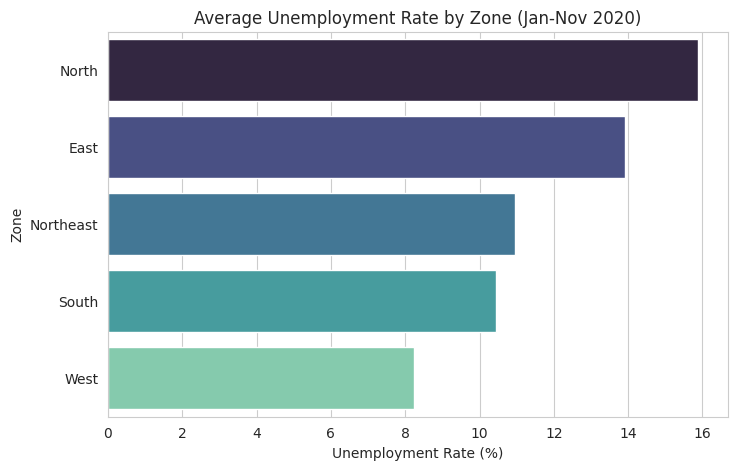

In [18]:
df2_renamed = df2.rename(columns={'Estimated Unemployment Rate (%)': 'Unemployment_Rate'})
zone_avg = df2_renamed.groupby('Zone')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=zone_avg.values, y=zone_avg.index, hue=zone_avg.index, palette='mako', legend=False)
plt.title("Average Unemployment Rate by Zone (Jan-Nov 2020)")
plt.xlabel("Unemployment Rate (%)")
plt.savefig("screenshots/08_zonal_avg.png", dpi=100, bbox_inches='tight')
plt.show()


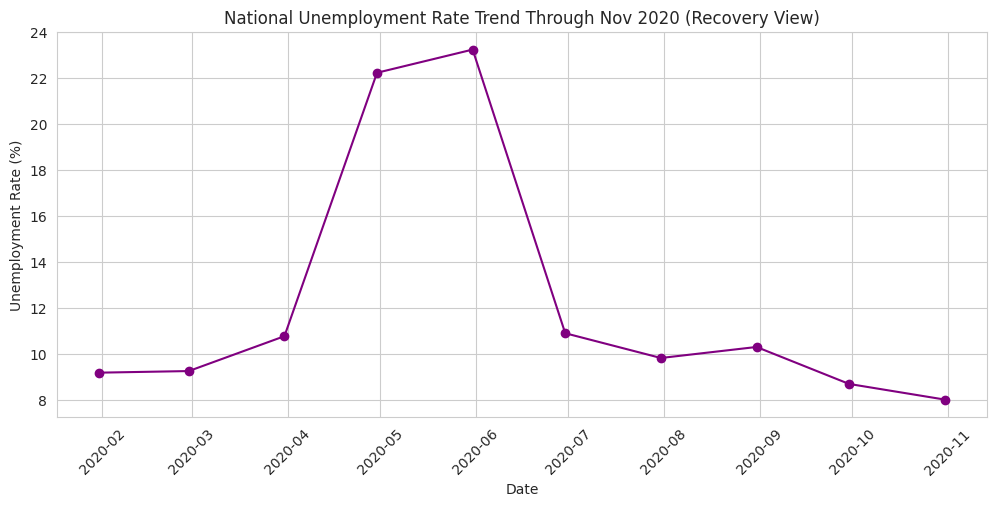

In [19]:
zone_monthly = df2_renamed.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(12,5))
plt.plot(zone_monthly.index, zone_monthly.values, marker='o', color='purple')
plt.title("National Unemployment Rate Trend Through Nov 2020 (Recovery View)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.savefig("screenshots/09_recovery_trend.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The extended view confirms the pattern: unemployment rate peaks sharply 
in April-May 2020 (22-23%), then drops back down to roughly 9-11% by June-October 2020 — 
close to pre-lockdown levels. This suggests the labour market largely recovered within 
about 4-6 months, rather than settling at a permanently higher baseline. At the zonal 
level, the North zone had the highest average unemployment rate (15.9%) over this window, 
while the West zone had the lowest (8.2%).

## 6. Conclusions

- **National impact:** Average unemployment rate roughly doubled due to COVID-19, rising 
  from 9.5% pre-lockdown to 17.8% in the immediate post-lockdown window.
- **Hardest hit states:** Puducherry, Tamil Nadu, and Jharkhand saw the largest jumps in 
  unemployment rate following the lockdown, while Tripura and Haryana had the highest 
  unemployment rates overall across the full period (a structural issue, not purely a 
  COVID effect).
- **Rural vs. urban:** Urban areas experienced a higher median unemployment rate (9.97%) 
  and more volatility than rural areas (6.76%), consistent with urban economies' greater 
  reliance on in-person and formal-sector work.
- **Correlations:** Unemployment rate correlates weakly negatively with employed 
  population (-0.22) and shows almost no correlation with labour participation rate 
  (0.003) in this dataset.
- **Recovery:** The extended zonal dataset (through Oct 2020) shows unemployment peaking 
  at 22-23% in April-May 2020 before recovering to roughly pre-COVID levels (9-11%) by 
  June onward — indicating a sharp but largely temporary shock rather than a permanent 
  shift in the labour market.

## 7. Tech Stack
Python, pandas, numpy, matplotlib, seaborn, Jupyter Notebook
